# WESAD Heart Rate Data Preprocessing

This notebook loads the WESAD (Wearable Stress and Affect Detection) dataset,
extracts heart rate related features from the E4 wristband data, and produces
a clean CSV ready for machine learning.

**Data used (camera+flash derivable only):**
- `IBI.csv` — Inter-Beat Intervals (time between heartbeats) from the PPG sensor
- `HR.csv` — Average heart rate
- `*_quest.csv` — Protocol timing (condition start/end times)
- `*_readme.txt` — Subject demographics (age, gender, height, weight)

> All HRV features below can be computed from PPG captured by a phone camera+flash.
> Demographics (age, gender, height, weight) come from user profile and are **optional**.
> EDA, temperature, accelerometer, or other wristband-only sensors are not used.

**Conditions (labels):**
| Label | Condition | Description |
|-------|-----------|-------------|
| 0 | Baseline | Relaxed, neutral state |
| 1 | Stress | Trier Social Stress Test (TSST) |
| 2 | Amusement | Watching funny videos |
| 3 | Meditation | Guided meditation |

**HRV Features extracted (per 60-second window):**

*Time-domain:*
- `sdnn`, `median_rr`, `cv_rr` — RR interval stats
- `rmssd`, `pnn50`, `pnn20` — Successive difference stats
- `mean_hr`, `std_hr`, `min_hr`, `max_hr`, `hr_range` — Heart rate stats

*Frequency-domain (from RR interval PSD):*
- `lf_power` — Low-frequency power (0.04–0.15 Hz) — sympathetic + parasympathetic
- `hf_power` — High-frequency power (0.15–0.40 Hz) — parasympathetic (vagal)
- `lf_hf_ratio` — LF/HF ratio — sympathovagal balance (higher = more stress)
- `total_power`, `lf_norm` — Normalized LF spectral measure

*Nonlinear:*
- `sd1` — Poincare plot short-axis (beat-to-beat variability)
- `sd2` — Poincare plot long-axis (long-term variability)
- `sd_ratio` — SD2/SD1 ratio

*Demographics (optional, from user profile):*
- `age` — Age in years
- `gender_male` — Binary gender encoding (1=male, 0=female)
- `height_cm` — Height in centimeters
- `weight_kg` — Weight in kilograms

**Removed redundant features** (to reduce multicollinearity):
- `mean_rr` — perfectly inversely correlated with `mean_hr` (RR = 60000/HR)
- `sdsd` — nearly identical to `rmssd` for any reasonable sample size
- `hf_norm` — perfectly negatively correlated with `lf_norm` (sum = 100%)
- `num_beats` — quality metric, not an HRV feature

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.interpolate import interp1d
from scipy.signal import welch

warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────
DATASET_ROOT = Path.home() / 'Downloads' / 'archive' / 'WESAD'
OUTPUT_DIR   = Path.cwd()
WINDOW_SEC   = 60     # HRV window length in seconds
STEP_SEC     = 30     # Window step (overlap = WINDOW - STEP)
MIN_BEATS    = 10     # Minimum beats in a window to compute HRV

# Label mapping for the conditions
CONDITION_LABELS = {
    'Base':   0,   # Baseline
    'TSST':   1,   # Stress
    'Fun':    2,   # Amusement
    'Medi 1': 3,   # Meditation 1
    'Medi 2': 3,   # Meditation 2
}

LABEL_NAMES = {0: 'Baseline', 1: 'Stress', 2: 'Amusement', 3: 'Meditation'}

print(f'Dataset root: {DATASET_ROOT}')
subjects = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
print(f'Found {len(subjects)} subjects: {[s.name for s in subjects]}')

Dataset root: /Users/vesco/Downloads/archive/WESAD
Found 15 subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


## 1. Helper functions
Parse the E4 data files and the questionnaire/readme files.

In [2]:
# Load IBI.csv → DataFrame with columns [time_offset_s, ibi_s].
# Line 1 of IBI.csv is the session start timestamp.
# Remaining lines: time_offset(s), ibi_duration(s)
def load_ibi(subject_dir: Path) -> pd.DataFrame:
    sid = subject_dir.name
    ibi_path = subject_dir / f'{sid}_E4_Data' / 'IBI.csv'
    
    with open(ibi_path) as f:
        header_line = f.readline().strip()  # "timestamp, IBI"
        session_start = float(header_line.split(',')[0])
    
    df = pd.read_csv(ibi_path, skiprows=1, header=None, names=['time_offset_s', 'ibi_s'])
    df['ibi_ms'] = df['ibi_s'] * 1000  # convert to milliseconds
    df['hr_bpm'] = 60.0 / df['ibi_s']   # instantaneous HR
    df['abs_time_min'] = df['time_offset_s'] / 60.0  # offset in minutes
    return df, session_start

# Load HR.csv → DataFrame with 1-Hz heart rate.
def load_hr(subject_dir: Path) -> pd.DataFrame:
    sid = subject_dir.name
    hr_path = subject_dir / f'{sid}_E4_Data' / 'HR.csv'
    
    with open(hr_path) as f:
        _ = f.readline()  # skip session start timestamp
        sample_rate = float(f.readline().strip())
    
    df = pd.read_csv(hr_path, skiprows=2, header=None, names=['hr_bpm'])
    df['time_offset_s'] = np.arange(len(df)) / sample_rate
    return df

# Parse *_quest.csv to get condition → (start_min, end_min).
def parse_conditions(subject_dir: Path) -> dict:
    sid = subject_dir.name
    quest_path = subject_dir / f'{sid}_quest.csv'
    
    with open(quest_path, encoding='utf-8-sig') as f:
        lines = f.readlines()
    
    order_line = start_line = end_line = None
    for line in lines:
        line = line.strip()
        if line.startswith('# ORDER'):
            order_line = line
        elif line.startswith('# START'):
            start_line = line
        elif line.startswith('# END'):
            end_line = line
    
    if not all([order_line, start_line, end_line]):
        return {}
    
    conditions = [c.strip() for c in order_line.split(';')[1:] if c.strip()]
    starts     = [s.strip() for s in start_line.split(';')[1:] if s.strip()]
    ends       = [e.strip() for e in end_line.split(';')[1:] if e.strip()]
    
    result = {}
    for cond, s, e in zip(conditions, starts, ends):
        try:
            result[cond] = (float(s), float(e))
        except ValueError:
            continue
    return result

# Parse *_readme.txt for age, gender, height, weight.
def parse_demographics(subject_dir: Path) -> dict:
    sid = subject_dir.name
    readme_path = subject_dir / f'{sid}_readme.txt'
    
    info = {'subject': sid}
    try:
        text = readme_path.read_text(encoding='utf-8')
        for line in text.splitlines():
            if 'Age:' in line:
                info['age'] = int(re.search(r'\d+', line).group())
            elif 'Gender:' in line:
                info['gender'] = line.split(':')[1].strip().lower()
            elif 'Height' in line:
                info['height_cm'] = int(re.search(r'\d+', line.split(':')[1]).group())
            elif 'Weight' in line:
                info['weight_kg'] = int(re.search(r'\d+', line.split(':')[1]).group())
    except Exception:
        pass
    return info


# Quick test
test_dir = subjects[0]
ibi_df, _ = load_ibi(test_dir)
conds = parse_conditions(test_dir)
demo = parse_demographics(test_dir)
print(f'{test_dir.name}: {len(ibi_df)} IBI samples, conditions={list(conds.keys())}')
print(f'Demographics: {demo}')
ibi_df.head()

S10: 5176 IBI samples, conditions=['Base', 'Fun', 'Medi 1', 'TSST', 'Medi 2', 'bRead', 'fRead', 'sRead']
Demographics: {'subject': 'S10', 'age': 28, 'height_cm': 178, 'weight_kg': 76, 'gender': 'male'}


,time_offset_s,ibi_s,ibi_ms,hr_bpm,abs_time_min
0,15.656967,0.750034,750.034,79.996373,0.260949
1,16.360124,0.703157,703.157,85.329450,0.272669
2,17.110158,0.750034,750.034,79.996373,0.285169
3,17.828941,0.718783,718.783,83.474428,0.297149
4,18.578975,0.750034,750.034,79.996373,0.309650


## 2. HRV Feature Extraction

Compute time-domain, frequency-domain, and nonlinear HRV features from RR intervals in sliding windows.
All features are derivable from PPG data (camera+flash) — no other sensors needed.

In [3]:
# Compute time-domain + frequency-domain + nonlinear HRV features
# from an array of RR intervals (in ms).
# All derivable from camera+flash PPG only.
#
# Removed redundant features to avoid multicollinearity:
#   - num_beats: quality metric, not an HRV feature (leaks window/condition info)
#   - sdsd: nearly identical to rmssd for any reasonable sample size
#   - hf_norm: = 100 - lf_norm by definition (perfectly negatively correlated)
#   - mean_rr: = 60000/mean_hr by definition (perfectly inversely correlated)

# Use np.trapezoid (NumPy 2.0+) with fallback to np.trapz for older versions
_trapz = getattr(np, 'trapezoid', None) or np.trapz

def compute_hrv_features(rr_intervals_ms: np.ndarray) -> dict:
    rr = rr_intervals_ms.copy()
    if len(rr) < MIN_BEATS:
        return None
    
    # Outlier filtering: keep physiological range 300–2000 ms (30–200 BPM)
    rr = rr[(rr >= 300) & (rr <= 2000)]
    if len(rr) < MIN_BEATS:
        return None
    
    # Successive differences
    diff_rr = np.diff(rr)
    
    # Heart rates from each RR interval
    hr = 60000.0 / rr  # BPM
    
    features = {}
    
    # ═══ TIME-DOMAIN ═══
    features['sdnn']      = np.std(rr, ddof=1) if len(rr) > 1 else 0
    features['median_rr'] = np.median(rr)
    features['cv_rr']     = (np.std(rr, ddof=1) / np.mean(rr)) if np.mean(rr) > 0 else 0
    
    features['rmssd'] = np.sqrt(np.mean(diff_rr ** 2)) if len(diff_rr) > 0 else 0
    features['pnn50'] = (np.sum(np.abs(diff_rr) > 50) / len(diff_rr) * 100) if len(diff_rr) > 0 else 0
    features['pnn20'] = (np.sum(np.abs(diff_rr) > 20) / len(diff_rr) * 100) if len(diff_rr) > 0 else 0
    
    features['mean_hr']  = np.mean(hr)
    features['std_hr']   = np.std(hr, ddof=1) if len(hr) > 1 else 0
    features['min_hr']   = np.min(hr)
    features['max_hr']   = np.max(hr)
    features['hr_range'] = np.max(hr) - np.min(hr)
    
    # ═══ FREQUENCY-DOMAIN (Welch PSD on interpolated RR) ═══
    freq_defaults = {'lf_power': 0, 'hf_power': 0, 'lf_hf_ratio': 0,
                     'total_power': 0, 'lf_norm': 0}
    try:
        if len(rr) >= 20:
            rr_s = rr / 1000.0
            t_rr = np.cumsum(rr_s) - rr_s[0]
            
            # Interpolate to uniform 4 Hz
            fs = 4.0
            t_uniform = np.arange(t_rr[0], t_rr[-1], 1.0 / fs)
            if len(t_uniform) > 10:
                interp_func = interp1d(t_rr, rr, kind='cubic', fill_value='extrapolate')
                rr_uniform = interp_func(t_uniform)
                rr_uniform = rr_uniform - np.mean(rr_uniform)  # detrend
                
                freqs, psd = welch(rr_uniform, fs=fs,
                                   nperseg=min(len(rr_uniform), 128),
                                   noverlap=min(len(rr_uniform) // 2, 64))
                
                lf_mask = (freqs >= 0.04) & (freqs < 0.15)
                hf_mask = (freqs >= 0.15) & (freqs < 0.40)
                
                lf = _trapz(psd[lf_mask], freqs[lf_mask]) if lf_mask.any() else 0
                hf = _trapz(psd[hf_mask], freqs[hf_mask]) if hf_mask.any() else 0
                total = lf + hf
                
                features['lf_power']    = lf
                features['hf_power']    = hf
                features['lf_hf_ratio'] = lf / hf if hf > 0 else 0
                features['total_power'] = total
                features['lf_norm']     = (lf / total * 100) if total > 0 else 0
            else:
                features.update(freq_defaults)
        else:
            features.update(freq_defaults)
    except Exception:
        features.update(freq_defaults)
    
    # ═══ NONLINEAR: Poincare plot (SD1, SD2) ═══
    if len(diff_rr) > 0:
        features['sd1'] = np.std(diff_rr, ddof=1) / np.sqrt(2) if len(diff_rr) > 1 else 0
        features['sd2'] = np.sqrt(2 * np.std(rr, ddof=1)**2 - features['sd1']**2) \
                          if (2 * np.std(rr, ddof=1)**2 > features['sd1']**2) else 0
        features['sd_ratio'] = features['sd2'] / features['sd1'] if features['sd1'] > 0 else 0
    else:
        features['sd1'] = features['sd2'] = features['sd_ratio'] = 0
    
    return features


# Quick test
test_rr = ibi_df[ibi_df['time_offset_s'] < 60]['ibi_ms'].values
print(f'Test window: {len(test_rr)} beats')
feats = compute_hrv_features(test_rr)
if feats:
    for k, v in feats.items():
        print(f'  {k:15s}: {v:.4f}')

Test window: 25 beats
  sdnn           : 101.9191
  median_rr      : 718.7830
  cv_rr          : 0.1459
  rmssd          : 78.6476
  pnn50          : 25.0000
  pnn20          : 70.8333
  mean_hr        : 87.8780
  std_hr         : 14.4946
  min_hr         : 71.1078
  max_hr         : 119.9945
  hr_range       : 48.8867
  lf_power       : 768.1365
  hf_power       : 1261.0966
  lf_hf_ratio    : 0.6091
  total_power    : 2029.2331
  lf_norm        : 37.8535
  sd1            : 56.6134
  sd2            : 132.5516
  sd_ratio       : 2.3413


## 3. Process All Subjects

For each subject:
1. Load IBI data and condition timings
2. For each condition, extract the IBI segment
3. Slide a 60-second window (30s step) and compute HRV features
4. Attach the condition label and subject metadata

In [4]:
all_rows = []
skipped = []

for subj_dir in subjects:
    sid = subj_dir.name
    
    # Load data
    try:
        ibi_df, session_start = load_ibi(subj_dir)
        conditions = parse_conditions(subj_dir)
        demographics = parse_demographics(subj_dir)
    except Exception as e:
        print(f'  ⚠ {sid}: Error loading data — {e}')
        skipped.append(sid)
        continue
    
    print(f'\n── {sid} ──  IBI samples: {len(ibi_df)}, conditions: {list(conditions.keys())}')
    
    for cond_name, (start_min, end_min) in conditions.items():
        # Only keep conditions we have labels for
        if cond_name not in CONDITION_LABELS:
            continue
        
        label = CONDITION_LABELS[cond_name]
        label_name = LABEL_NAMES[label]
        
        # Convert to seconds and filter IBI data
        start_s = start_min * 60
        end_s   = end_min * 60
        mask = (ibi_df['time_offset_s'] >= start_s) & (ibi_df['time_offset_s'] < end_s)
        segment = ibi_df[mask]
        
        if len(segment) < MIN_BEATS:
            print(f'  {cond_name} ({label_name}): only {len(segment)} beats — skipping')
            continue
        
        # Sliding window
        window_start = start_s
        n_windows = 0
        while window_start + WINDOW_SEC <= end_s:
            window_end = window_start + WINDOW_SEC
            w_mask = (segment['time_offset_s'] >= window_start) & (segment['time_offset_s'] < window_end)
            w_rr = segment.loc[w_mask, 'ibi_ms'].values
            
            feats = compute_hrv_features(w_rr)
            if feats is not None:
                feats['subject'] = sid
                feats['condition'] = cond_name
                feats['label'] = label
                feats['label_name'] = label_name
                feats['window_start_s'] = window_start
                feats['window_end_s'] = window_end
                # Add demographics
                feats.update({k: v for k, v in demographics.items() if k != 'subject'})
                all_rows.append(feats)
                n_windows += 1
            
            window_start += STEP_SEC
        
        print(f'  {cond_name} ({label_name}): {len(segment)} beats → {n_windows} windows')

print(f'\nTotal feature windows: {len(all_rows)}')
if skipped:
    print(f'Skipped subjects: {skipped}')


── S10 ──  IBI samples: 5176, conditions: ['Base', 'Fun', 'Medi 1', 'TSST', 'Medi 2', 'bRead', 'fRead', 'sRead']
  Base (Baseline): 801 beats → 37 windows
  Fun (Amusement): 259 beats → 12 windows
  Medi 1 (Meditation): 412 beats → 12 windows
  TSST (Stress): 680 beats → 23 windows
  Medi 2 (Meditation): 255 beats → 10 windows

── S11 ──  IBI samples: 3278, conditions: ['Base', 'TSST', 'Medi 1', 'Fun', 'Medi 2', 'bRead', 'sRead', 'fRead']
  Base (Baseline): 584 beats → 35 windows
  TSST (Stress): 424 beats → 20 windows
  Medi 1 (Meditation): 103 beats → 6 windows
  Fun (Amusement): 278 beats → 11 windows
  Medi 2 (Meditation): 396 beats → 12 windows

── S13 ──  IBI samples: 2858, conditions: ['Base', 'Fun', 'Medi 1', 'TSST', 'Medi 2', 'bRead', 'fRead', 'sRead']
  Base (Baseline): 339 beats → 26 windows
  Fun (Amusement): 168 beats → 10 windows
  Medi 1 (Meditation): 209 beats → 11 windows
  TSST (Stress): 488 beats → 20 windows
  Medi 2 (Meditation): 114 beats → 3 windows

── S14 ──  

## 4. Build & Explore the Feature DataFrame

In [5]:
df = pd.DataFrame(all_rows)

# Encode gender as binary (1=male, 0=female) — usable as a numeric feature
df['gender_male'] = (df['gender'] == 'male').astype(int)
df.drop(columns=['gender'], inplace=True)

# Reorder columns: metadata first, demographics, then HRV features
meta_cols = ['subject', 'condition', 'label', 'label_name',
             'window_start_s', 'window_end_s']
demo_cols = ['age', 'gender_male', 'height_cm', 'weight_kg']
feat_cols = [c for c in df.columns if c not in meta_cols + demo_cols]
df = df[meta_cols + demo_cols + feat_cols]

# Data quality checks
nan_counts = df[feat_cols].isna().sum()
inf_counts = df[feat_cols].apply(lambda c: np.isinf(c).sum() if c.dtype != object else 0)

if nan_counts.any():
    print('NaN values found:')
    print(nan_counts[nan_counts > 0])
    df[feat_cols] = df[feat_cols].fillna(0)
    print('  Filled NaN with 0')
else:
    print('No NaN values')

if inf_counts.any():
    print('Inf values found:')
    print(inf_counts[inf_counts > 0])
    df[feat_cols] = df[feat_cols].replace([np.inf, -np.inf], 0)
    print('  Replaced inf with 0')
else:
    print('No infinite values')

print(f'\nShape: {df.shape}')
print(f'\nLabel distribution:')
print(df['label_name'].value_counts())
print(f'\nSubjects: {df["subject"].nunique()}')
print(f'\nDemographic columns: {demo_cols}')
print(f'HRV feature columns ({len(feat_cols)}): {feat_cols}')
df.head(10)

No NaN values
No infinite values

Shape: (1058, 29)

Label distribution:
label_name
Baseline      442
Stress        259
Meditation    220
Amusement     137
Name: count, dtype: int64

Subjects: 15

Demographic columns: ['age', 'gender_male', 'height_cm', 'weight_kg']
HRV feature columns (19): ['sdnn', 'median_rr', 'cv_rr', 'rmssd', 'pnn50', 'pnn20', 'mean_hr', 'std_hr', 'min_hr', 'max_hr', 'hr_range', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_norm', 'sd1', 'sd2', 'sd_ratio']


,subject,condition,label,label_name,window_start_s,window_end_s,age,gender_male,height_cm,weight_kg,...,max_hr,hr_range,lf_power,hf_power,lf_hf_ratio,total_power,lf_norm,sd1,sd2,sd_ratio
0,S10,Base,0,Baseline,150.0,210.0,28,1,178,76,...,109.709270,32.912809,251.690844,141.363611,1.780450,393.054455,64.034599,25.285273,71.447591,2.825660
1,S10,Base,0,Baseline,180.0,240.0,28,1,178,76,...,106.661737,23.187308,784.277153,381.840429,2.053940,1166.117582,67.255409,23.731141,50.603545,2.132369
2,S10,Base,0,Baseline,210.0,270.0,28,1,178,76,...,106.661737,26.665363,1194.583677,414.064271,2.885020,1608.647948,74.260106,20.410668,59.586817,2.919396
3,S10,Base,0,Baseline,240.0,300.0,28,1,178,76,...,106.661737,31.371020,132.383576,88.399568,1.497559,220.783143,59.960907,27.540784,75.730269,2.749750
4,S10,Base,0,Baseline,270.0,330.0,28,1,178,76,...,106.661737,31.371020,556.785570,982.752245,0.566557,1539.537815,36.165761,39.719867,76.851943,1.934849
5,S10,Base,0,Baseline,300.0,360.0,28,1,178,76,...,112.936074,41.828250,257.948877,195.972667,1.316249,453.921544,56.826754,32.781031,81.355325,2.481781
6,S10,Base,0,Baseline,330.0,390.0,28,1,178,76,...,112.936074,49.988161,1017.247186,391.207316,2.600276,1408.454502,72.224355,30.146598,113.915705,3.778725
7,S10,Base,0,Baseline,360.0,420.0,28,1,178,76,...,109.709270,46.761357,153.936380,190.161715,0.809502,344.098094,44.736191,33.221172,93.792601,2.823278
8,S10,Base,0,Baseline,390.0,450.0,28,1,178,76,...,109.709270,28.010925,184.451092,314.975879,0.585604,499.426971,36.932545,35.549397,40.501301,1.139296
9,S10,Base,0,Baseline,420.0,480.0,28,1,178,76,...,112.936074,19.281777,196.953793,267.621209,0.735942,464.575003,42.394402,22.155042,28.954893,1.306921


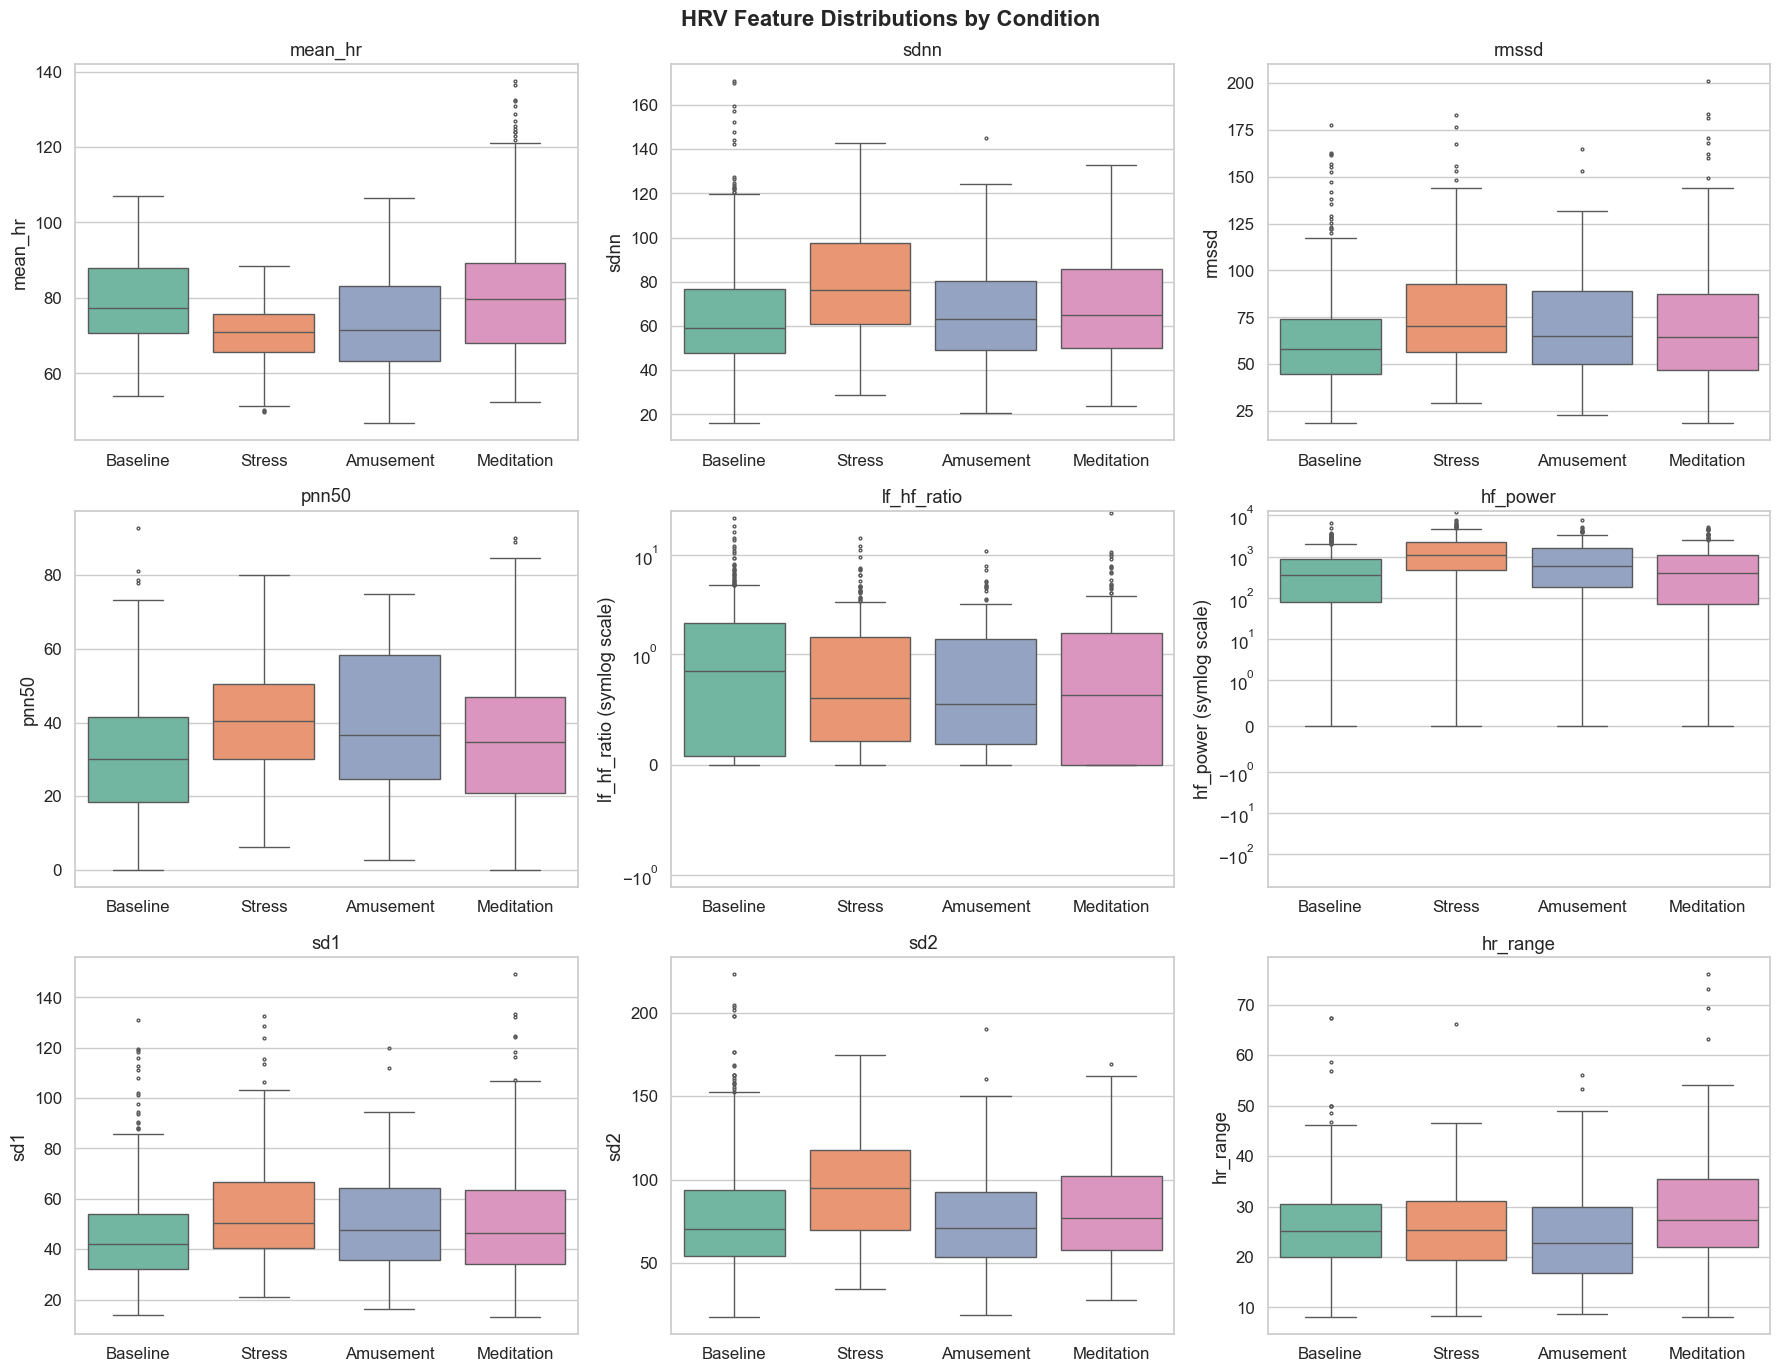

Saved: hrv_feature_distributions.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('HRV Feature Distributions by Condition', fontsize=16, fontweight='bold')

# Features to plot — one per domain, covering the key stress markers
plot_features = ['mean_hr', 'sdnn', 'rmssd', 'pnn50', 'lf_hf_ratio', 'hf_power',
                 'sd1', 'sd2', 'hr_range']
# Features with heavy right-skew — use log scale for better comparison
log_scale_features = {'lf_hf_ratio', 'hf_power', 'lf_power', 'total_power'}

for ax, feat in zip(axes.flat, plot_features):
    sns.boxplot(data=df, x='label_name', y=feat, ax=ax, palette='Set2',
                order=['Baseline', 'Stress', 'Amusement', 'Meditation'],
                fliersize=2)
    ax.set_title(feat)
    ax.set_xlabel('')
    if feat in log_scale_features:
        ax.set_yscale('symlog', linthresh=1)  # symlog handles zeros gracefully
        ax.set_ylabel(f'{feat} (symlog scale)')

plt.tight_layout()
plt.savefig('hrv_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hrv_feature_distributions.png')

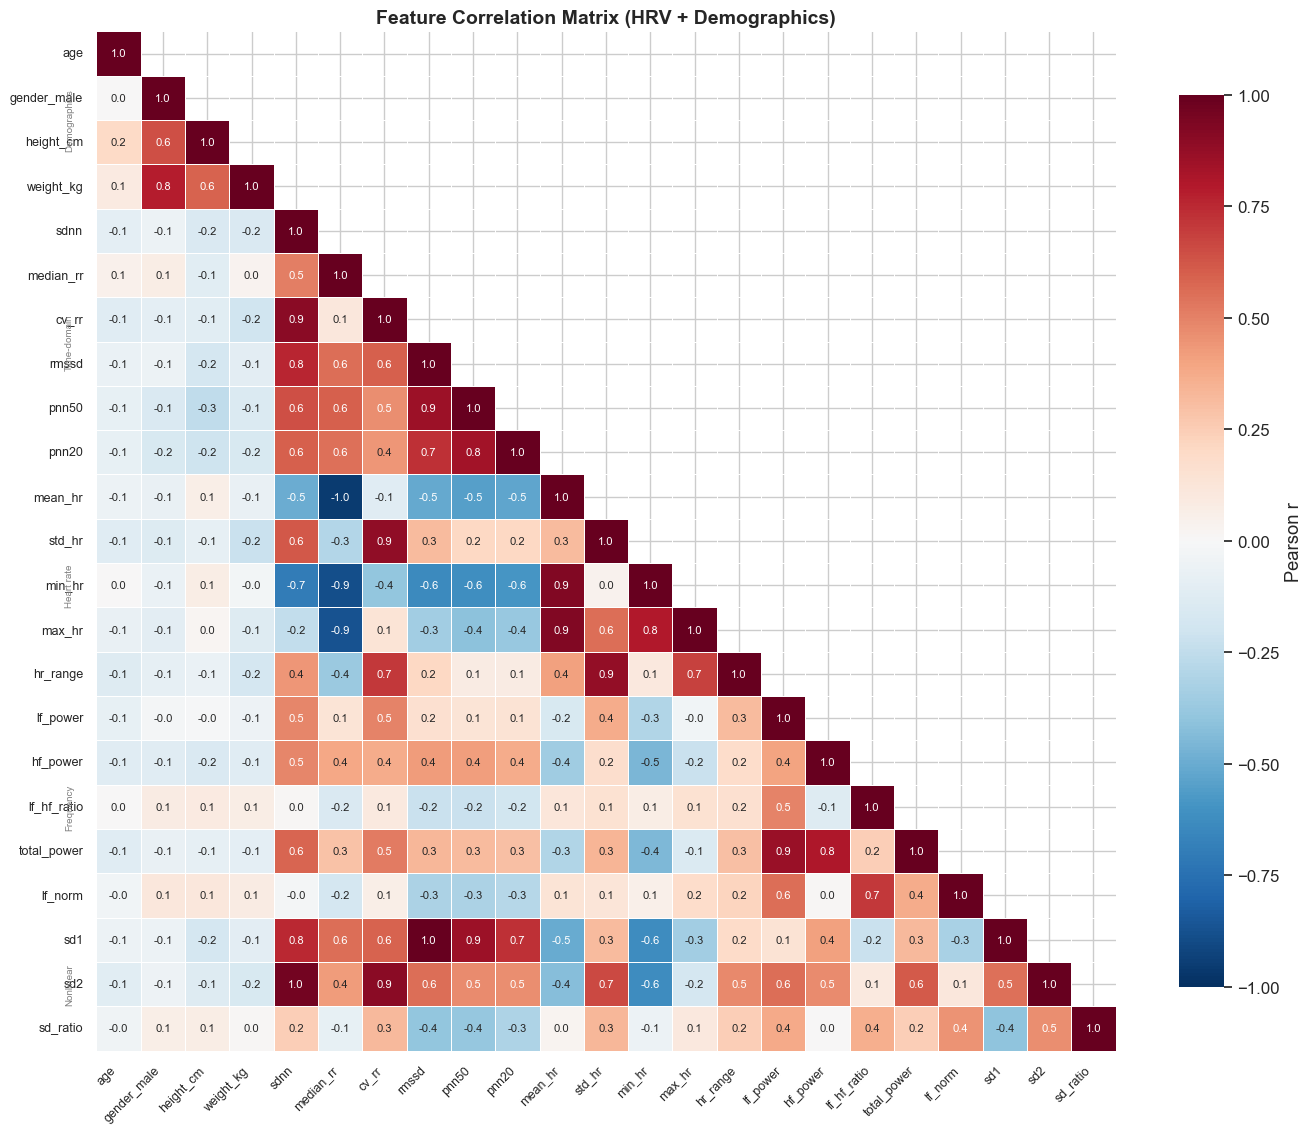


Highly correlated feature pairs (|r| > 0.85):
  sdnn            ↔ cv_rr            r=0.90
  sdnn            ↔ sd2              r=0.96
  median_rr       ↔ mean_hr          r=-0.96
  median_rr       ↔ min_hr           r=-0.88
  median_rr       ↔ max_hr           r=-0.87
  cv_rr           ↔ std_hr           r=0.88
  cv_rr           ↔ sd2              r=0.90
  rmssd           ↔ pnn50            r=0.86
  rmssd           ↔ sd1              r=1.00
  pnn50           ↔ sd1              r=0.85
  mean_hr         ↔ min_hr           r=0.93
  mean_hr         ↔ max_hr           r=0.93
  std_hr          ↔ hr_range         r=0.88
  lf_power        ↔ total_power      r=0.87

Saved: feature_correlation.png


In [7]:
# Correlation heatmap of all features (HRV + demographics)
# Use a triangle mask to avoid redundant mirroring, and order features by domain
numeric_feats = [c for c in df.columns if c not in
    ['subject', 'condition', 'label', 'label_name', 'window_start_s', 'window_end_s']]

# Order features by domain for cleaner visual grouping
feature_order = [
    # Demographics
    'age', 'gender_male', 'height_cm', 'weight_kg',
    # Time-domain
    'sdnn', 'median_rr', 'cv_rr', 'rmssd', 'pnn50', 'pnn20',
    # Heart rate
    'mean_hr', 'std_hr', 'min_hr', 'max_hr', 'hr_range',
    # Frequency-domain
    'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_norm',
    # Nonlinear
    'sd1', 'sd2', 'sd_ratio',
]
# Keep only features actually present in the DataFrame
feature_order = [f for f in feature_order if f in numeric_feats]

corr = df[feature_order].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # mask upper triangle

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix (HRV + Demographics)', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

# Add domain group indicators
domain_boundaries = {
    'Demographics': (0, 4), 'Time-domain': (4, 10),
    'Heart rate': (10, 15), 'Frequency': (15, 20), 'Nonlinear': (20, 23)
}
for name, (start, end) in domain_boundaries.items():
    if end <= len(feature_order):
        mid = (start + end) / 2
        ax.annotate(name, xy=(0, mid), xytext=(-0.5, mid),
                    fontsize=7, color='gray', ha='right', va='center', rotation=90)

plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs (|r| > 0.85) for awareness
print('\nHighly correlated feature pairs (|r| > 0.85):')
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            print(f'  {corr.columns[i]:15s} ↔ {corr.columns[j]:15s}  r={r:.2f}')
print('\nSaved: feature_correlation.png')

In [8]:
# Summary statistics per condition
summary = df.groupby('label_name')[numeric_feats].agg(['mean', 'std']).round(2)
summary

age       gender_male       height_cm       weight_kg         \
             mean   std        mean   std      mean   std      mean    std   
label_name                                                                   
Amusement   27.59  2.52        0.77  0.42    177.53  6.65     72.98  10.50   
Baseline    27.04  1.89        0.84  0.37    178.17  5.79     73.95   9.59   
Meditation  27.10  2.14        0.85  0.36    178.58  5.98     74.45   9.98   
Stress      27.12  1.67        0.79  0.41    177.16  6.10     72.58   9.83   

             sdnn         ... total_power          lf_norm           sd1  \
             mean    std  ...        mean      std    mean    std   mean   
label_name                ...                                              
Amusement   65.80  24.43  ...     2004.17  2061.71   37.17  27.07  51.36   
Baseline    64.91  25.97  ...     1502.55  1989.18   40.96  30.33  45.73   
Meditation  68.71  25.50  ...     1808.90  2125.32   37.19  29.90  51.70   
Stress      78.92  24.57  ...     3068.26  2701.75   38.98  25.85  54.75   

                     sd2        sd_ratio        
              std   mean    std     mean   std  
label_name                                      
Amusement   19.56  76.46  31.40     1.55  0.50  
Baseline    19.29  78.23  34.55     1.81  0.65  
Meditation  24.59  80.55  31.30     1.72  0.66  
Stress      19.80  95.68  33.47     1.86  0.70  

[4 rows x 46 columns]

## 5. Save Preprocessed Data

In [9]:
output_path = OUTPUT_DIR / 'hrv_features.csv'
df.to_csv(output_path, index=False)
print(f'✅ Saved preprocessed features to: {output_path}')
print(f'   Rows: {len(df)}, Columns: {len(df.columns)}')
print(f'   File size: {output_path.stat().st_size / 1024:.1f} KB')
print(f'\nColumn list:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2d}. {col}')

✅ Saved preprocessed features to: /Users/vesco/Documents/Projects/HeartRateMonitor ML/hrv_features.csv
   Rows: 1058, Columns: 29
   File size: 384.1 KB

Column list:
   1. subject
   2. condition
   3. label
   4. label_name
   5. window_start_s
   6. window_end_s
   7. age
   8. gender_male
   9. height_cm
  10. weight_kg
  11. sdnn
  12. median_rr
  13. cv_rr
  14. rmssd
  15. pnn50
  16. pnn20
  17. mean_hr
  18. std_hr
  19. min_hr
  20. max_hr
  21. hr_range
  22. lf_power
  23. hf_power
  24. lf_hf_ratio
  25. total_power
  26. lf_norm
  27. sd1
  28. sd2
  29. sd_ratio
